### Essential libraries

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np

import math
from scipy import stats

import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path


import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import time

import optuna
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")


In [2]:
print("Data Preprocessing & Feature Engineering")
print("="*60)
print("Dataset: Customers Churn data (17 features)")
print("Goal: Transform raw data into ML-ready features")

Data Preprocessing & Feature Engineering
Dataset: Customers Churn data (17 features)
Goal: Transform raw data into ML-ready features


### Load  Dataset
Loading the TeleCo Customer Churn dataset with Cutomers Id's, Tenure, Contract Type, Avg Monthly GB usage and churned data.

In [ ]:
# Folder containing CSV files
folder_path = Path(r"D:\Churn_Prediction\data\Pre_processed_data")

# Get all CSV files
csv_files = list(folder_path.glob("*.csv"))

if not csv_files:
    print("No CSV files found in the folder.")
else:
    # Load the first CSV file
    data_path = csv_files[0]

    try:
        df = pd.read_csv(data_path)
        print(f"Successfully loaded: {data_path.name}")
        print(f"\nDataset shape: {df.shape}")
        print(f"\nColumns: {df.columns}")
    except Exception as e:
        print(f"Error: {e}")

Successfully loaded: char_data_v1_20260721_161051.csv

Dataset shape: (5000, 17)

Columns: Index(['customer_id', 'age', 'gender', 'tenure_months', 'contract_type',
       'monthly_charges', 'total_charges', 'internet_service', 'phone_service',
       'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes',
       'satisfaction_score', 'payment_method', 'num_additional_services',
       'last_interaction_date', 'churned'],
      dtype='object')


##  Part 1: Data Exploration

In [4]:
# Quick data overview
print(f"Total Customers: {len(df)}")
print(f"Features: {df.shape[1]}")
print("\nFirst 3 records:")
df.head(3)

Total Customers: 5000
Features: 17

First 3 records:


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-000001,49.450712,Female,11.013923,One year,65.89,896.60,Fiber optic,Yes,5.60,3.0,446.3,6.5,Bank transfer,4,2024-06-30,1
1,TC-000002,39.926035,Female,6.079738,One year,63.70,207.91,DSL,No,15.08,0.0,297.7,6.2,Credit card,3,2024-06-04,1
2,TC-000003,51.715328,Female,40.524233,Month-to-month,57.23,2533.53,Fiber optic,Yes,2.49,2.0,113.6,3.7,Electronic check,1,2024-06-23,1


#### Comprehensive Dataset Overview

Our customer churn dataset contains multiple categories of features that provide a comprehensive view of each customer's profile, service usage, billing behavior, and overall satisfaction.

**Column Categories:**

- **Customer Identity:** customer_id
- **Demographics:** age, gender
- **Account Information:** tenure_months, contract_type
- **Billing & Payments:** monthly_charges, total_charges, payment_method
- **Services Subscribed:** internet_service, phone_service, num_additional_services
- **Usage Metrics:** avg_monthly_gb_used, avg_monthly_minutes
- **Customer Support & Engagement:** num_support_tickets, last_interaction_date
- **Customer Satisfaction:** satisfaction_score
- **Target Variable:** churned

#### Data Quality Assessment

In [5]:
# Check data types and missing values
print("\nDATA QUALITY CHECK")
print("="*30)
print("\nData Types:")
print(df.dtypes)
# print(f"\nMissing Values:")
# missing_summary = df.isnull().sum()
# print(missing_summary[missing_summary > 0])
# print(f"\nDuplicate Records: {df.duplicated().sum()}")


DATA QUALITY CHECK

Data Types:
customer_id                 object
age                        float64
gender                      object
tenure_months              float64
contract_type               object
monthly_charges            float64
total_charges              float64
internet_service            object
phone_service               object
avg_monthly_gb_used        float64
num_support_tickets        float64
avg_monthly_minutes        float64
satisfaction_score         float64
payment_method              object
num_additional_services      int64
last_interaction_date       object
churned                      int64
dtype: object


In [6]:
print(f"\nMissing Values:")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])
print(f"\nDuplicate Records: {df.duplicated().sum()}")


Missing Values:
age                    30
gender                 50
total_charges          22
num_support_tickets    10
payment_method         30
dtype: int64

Duplicate Records: 0


In [7]:
print("\nDataFrame Info:")
df.info(verbose = True) 


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5000 non-null   object 
 1   age                      4970 non-null   float64
 2   gender                   4950 non-null   object 
 3   tenure_months            5000 non-null   float64
 4   contract_type            5000 non-null   object 
 5   monthly_charges          5000 non-null   float64
 6   total_charges            4978 non-null   float64
 7   internet_service         5000 non-null   object 
 8   phone_service            5000 non-null   object 
 9   avg_monthly_gb_used      5000 non-null   float64
 10  num_support_tickets      4990 non-null   float64
 11  avg_monthly_minutes      5000 non-null   float64
 12  satisfaction_score       5000 non-null   float64
 13  payment_method           4970 non-null   object 
 14  num_add

In [8]:
# Statistical summary for numerical columns
print("NUMERICAL FEATURES SUMMARY")
print("="*26)
df.describe().T

NUMERICAL FEATURES SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,4970.0,42.424486,14.190728,18.00,32.126769,42.210589,51.994527,85.00
tenure_months,5000.0,24.012170,23.391669,1.00,6.879298,16.510977,33.758150,120.00
monthly_charges,5000.0,65.146606,24.561247,0.00,47.807500,65.110000,82.180000,150.00
total_charges,4978.0,1645.915366,4201.398453,0.66,372.920000,957.555000,2125.100000,218681.58
avg_monthly_gb_used,5000.0,15.418397,15.337023,0.00,4.487500,10.450000,21.742500,119.67
num_support_tickets,4990.0,1.979359,1.402320,0.00,1.000000,2.000000,3.000000,8.00
avg_monthly_minutes,5000.0,297.266080,119.542894,0.00,214.100000,297.100000,376.900000,747.50
satisfaction_score,5000.0,5.927060,1.871424,0.00,4.700000,6.000000,7.225000,10.00
num_additional_services,5000.0,2.483400,1.711464,0.00,1.000000,2.000000,4.000000,5.00
churned,5000.0,0.364600,0.481366,0.00,0.000000,0.000000,1.000000,1.00


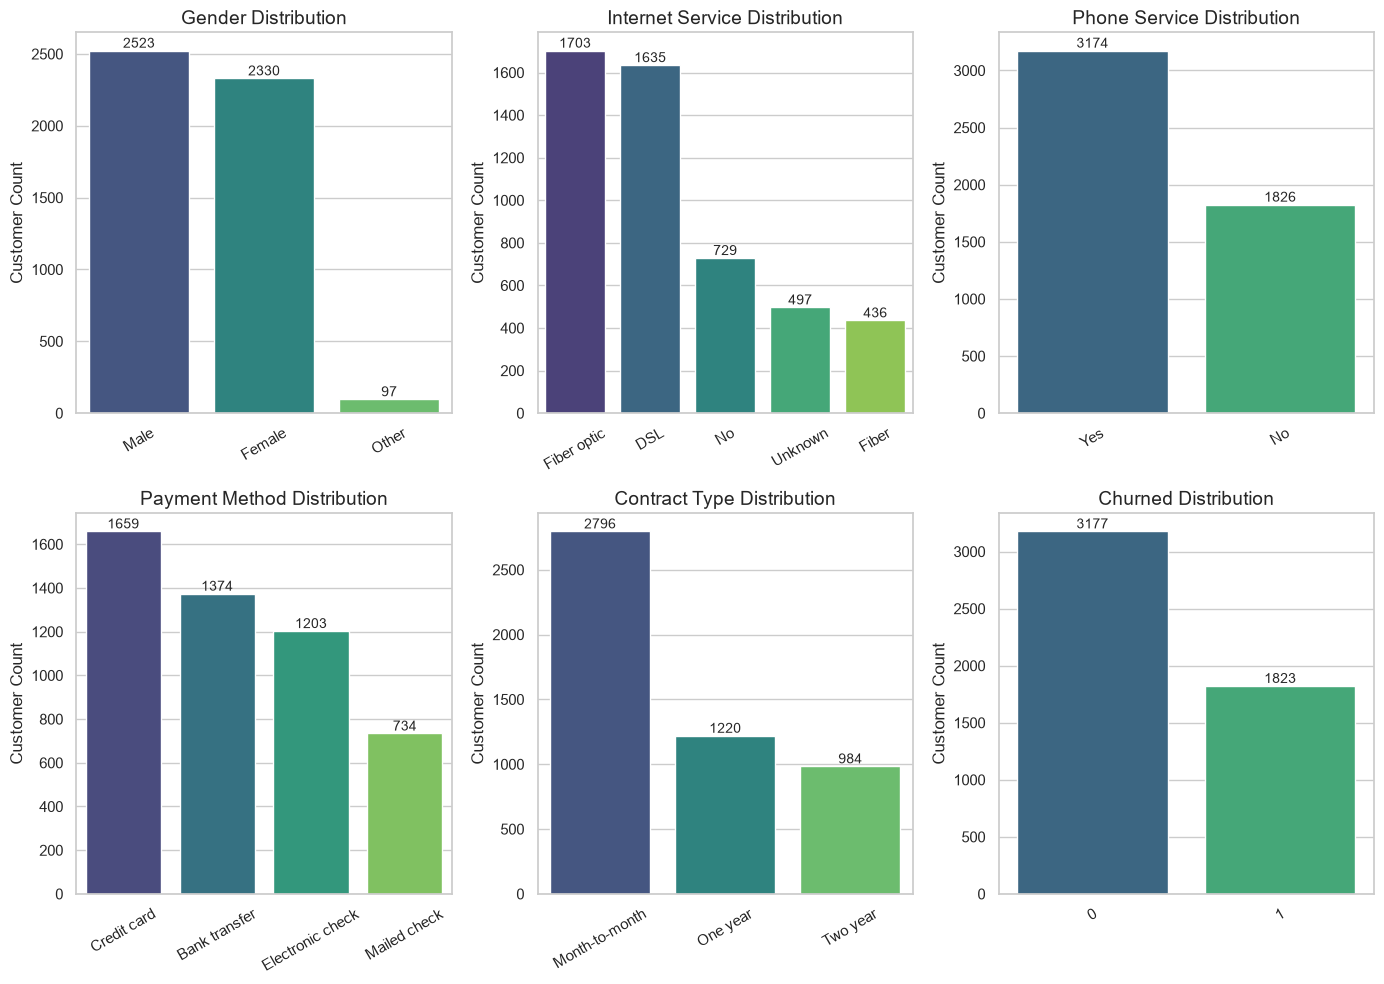

In [9]:
cols = ['gender', 'internet_service', 'phone_service', 'payment_method', 'contract_type', 'churned']

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df,
        x=col,
        order=order,
        palette="viridis",
        ax=ax
    )
    
    ax.set_title(f"{col.replace('_', ' ').title()} Distribution", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("Customer Count")
    ax.tick_params(axis='x', rotation=30)
    
    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

correlation = df[numeric_cols].corr()['churned'].sort_values(ascending=False)

print(correlation)

churned                    1.000000
num_support_tickets        0.041145
age                        0.003232
num_additional_services   -0.002729
monthly_charges           -0.003863
avg_monthly_gb_used       -0.008861
avg_monthly_minutes       -0.018836
total_charges             -0.044526
tenure_months             -0.081618
satisfaction_score        -0.126248
Name: churned, dtype: float64


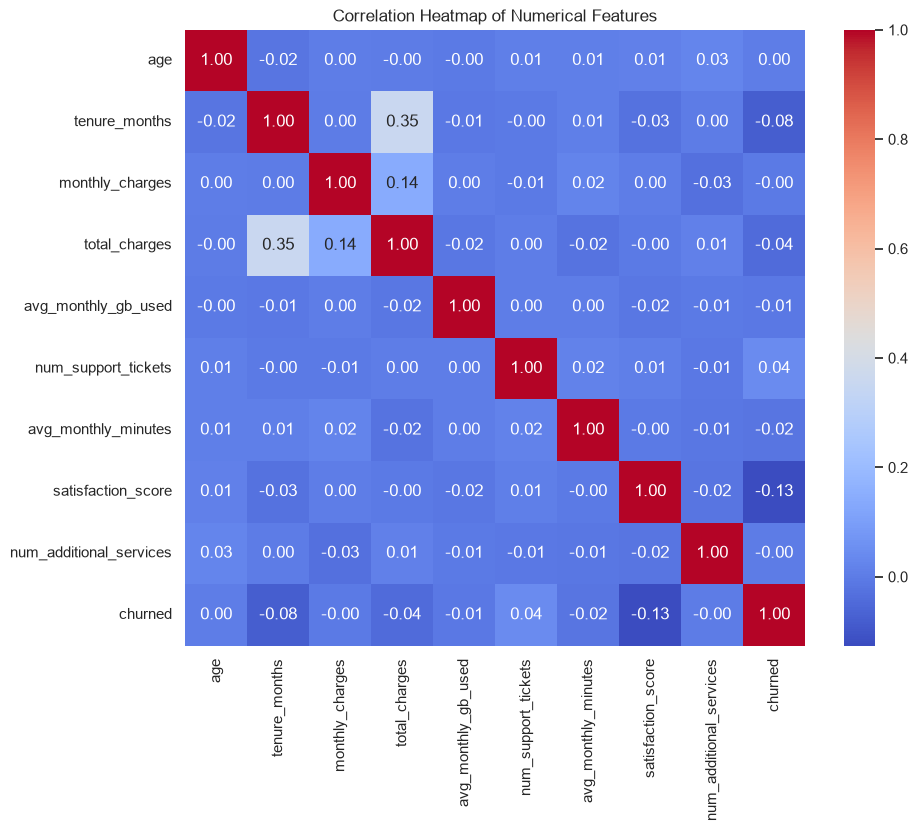

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Part 2: Encoding and Scaling Strategy

### Data Cleaning

#### Convert Date Column

In [12]:
df["last_interaction_date"] = pd.to_datetime(
    df["last_interaction_date"]
)

In [13]:
df["interaction_year"] = (
    df["last_interaction_date"].dt.year
)

df["interaction_month"] = (
    df["last_interaction_date"].dt.month
)

df["interaction_day"] = (
    df["last_interaction_date"].dt.day
)


# Drop original date
df.drop(
    columns=["last_interaction_date"],
    inplace=True
)

#### Remove Customer Identifier

In [14]:
df.drop(
    columns=["customer_id"],
    inplace=True
)

#### Split Features and Target

In [15]:
X = df.drop(
    columns=["churned"]
)

y = df["churned"]


print(X.shape)
print(y.value_counts())

(5000, 17)
churned
0    3177
1    1823
Name: count, dtype: int64


#### Identify Feature Types

In [16]:
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns


categorical_features = X.select_dtypes(
    include=["object"]
).columns


print("Numerical:")
print(list(numeric_features))


print("\nCategorical:")
print(list(categorical_features))

Numerical:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes', 'satisfaction_score', 'num_additional_services']

Categorical:
['gender', 'contract_type', 'internet_service', 'phone_service', 'payment_method']


### Preprocessing Pipeline

In [17]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [18]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [20]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

### Train Test Split

In [21]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Churn rate in training: {y_train.mean():.2%}")

Training samples: 4000
Test samples: 1000
Churn rate in training: 36.45%


In [22]:
X_train.head()

,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,interaction_year,interaction_month,interaction_day
177,63.803011,Female,4.606408,Two year,117.24,458.79,No,Yes,20.81,1.0,492.4,7.4,Bank transfer,1,2024,5,16
1253,47.610849,Male,22.371832,Month-to-month,61.23,1405.37,DSL,No,32.93,2.0,265.2,6.7,Bank transfer,2,2024,6,28
477,46.668752,Male,43.842647,Month-to-month,75.81,3345.09,DSL,Yes,20.26,3.0,139.2,5.2,Credit card,1,2024,6,26
540,54.535382,Male,1.000000,Month-to-month,82.40,129.63,No,Yes,3.23,3.0,403.4,3.7,Credit card,2,2024,5,31
2878,46.382891,Female,23.510595,Two year,83.98,2082.87,Unknown,No,21.17,4.0,292.8,6.0,Bank transfer,5,2024,6,30


### The Manual Tuning 

In [23]:
# Manual Attempt 1: Default parameters
print("\n" + "="*60)
print("MANUAL ATTEMPT 1: Default Parameters")
print("="*60)

# X_train_processed = preprocessor.fit_transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

start_time = time.time()
# model1 = RandomForestClassifier(random_state=42)

model1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, pred1)
time1 = time.time() - start_time

print(f"Parameters: n_estimators=100, max_depth=None, min_samples_split=2")
print(f"Accuracy: {acc1:.4f}")
print(f"Time: {time1:.2f} seconds")
print(f"❌ Below 85% target!")


MANUAL ATTEMPT 1: Default Parameters
Parameters: n_estimators=100, max_depth=None, min_samples_split=2
Accuracy: 0.6600
Time: 1.49 seconds
❌ Below 85% target!


In [24]:
# Manual Attempt 2: "Let's try more trees!"
print("\n" + "="*60)
print("MANUAL ATTEMPT 2: More Trees (Stack Overflow suggestion)")
print("="*60)

start_time = time.time()

model2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200,random_state=42))
    ]
)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, pred2)
time2 = time.time() - start_time

print(f"Parameters: n_estimators=200, max_depth=None, min_samples_split=2")
print(f"Accuracy: {acc2:.4f}")
print(f"Time: {time2:.2f} seconds")
print(f"❌ Still below target!")


MANUAL ATTEMPT 2: More Trees (Stack Overflow suggestion)
Parameters: n_estimators=200, max_depth=None, min_samples_split=2
Accuracy: 0.6680
Time: 2.60 seconds
❌ Still below target!


In [25]:
# Manual Attempt 3: Random guessing
print("\n" + "="*60)
print("MANUAL ATTEMPT 3: Random Values (Desperation Mode)")
print("="*60)

start_time = time.time()
model3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=5,
        random_state=42 ))
    ]
)
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)
acc3 = accuracy_score(y_test, pred3)
time3 = time.time() - start_time

print(f"Parameters: n_estimators=150, max_depth=10, min_samples_split=5")
print(f"Accuracy: {acc3:.4f}")
print(f"Time: {time3:.2f} seconds")
if acc3 > acc2:
    print(f"✅ Better! But was it luck or science?")
else:
    print(f"❌ Worse! Wasted time!")


MANUAL ATTEMPT 3: Random Values (Desperation Mode)
Parameters: n_estimators=150, max_depth=10, min_samples_split=5
Accuracy: 0.6600
Time: 1.54 seconds
❌ Worse! Wasted time!


### 🔥 Production Problems with Manual Tuning

1. **Non-Reproducible**: Which combination did we try? Can we recreate it?
2. **No Tracking**: No systematic record of what works and what doesn't
3. **Inefficient**: We might have tried 50 combinations to get here
4. **No Collaboration**: If colleague tries tomorrow, they start from scratch
5. **No CI/CD Integration**: How do you automate this chaos?
6. **No Explanation**: Why did max_depth=10 work? We have no idea!

**Real Cost:** If this takes 1 hour per model, and  10 models in production,  burning 10 hours. Per month? 40 hours. Per quarter? 120 hours = 3 full work weeks!

In [26]:
# Let's calculate the actual cost
attempts_made = 3
total_time = time1 + time2 + time3
avg_time_per_attempt = total_time / attempts_made

# Realistic scenario: 50-100 attempts to find good params
estimated_time_for_50_attempts = avg_time_per_attempt * 50 / 60  # in minutes
estimated_cost_per_model = estimated_time_for_50_attempts / 60  # in hours

# If you have 10 models in production
num_models = 10
quarterly_retuning = 4  # retune quarterly

annual_hours_wasted = estimated_cost_per_model * num_models * quarterly_retuning

print("\n" + "="*60)
print("💰 THE REAL COST OF MANUAL TUNING")
print("="*60)
print(f"Average time per attempt: {avg_time_per_attempt:.2f} seconds")
print(f"Estimated time for 50 attempts: {estimated_time_for_50_attempts:.1f} minutes")
print(f"Time per model: {estimated_cost_per_model:.2f} hours")
print(f"\nWith {num_models} production models retuned quarterly:")
print(f"Annual engineer hours wasted: {annual_hours_wasted:.0f} hours")
print(f"That's {annual_hours_wasted/40:.1f} full work weeks!")
print(f"\nAt ₹2,000/hour engineer cost: ₹{annual_hours_wasted * 2000:,.0f} per year!")
print("\n❌ AND you still don't know if you found the optimal parameters!")


💰 THE REAL COST OF MANUAL TUNING
Average time per attempt: 1.88 seconds
Estimated time for 50 attempts: 1.6 minutes
Time per model: 0.03 hours

With 10 production models retuned quarterly:
Annual engineer hours wasted: 1 hours
That's 0.0 full work weeks!

At ₹2,000/hour engineer cost: ₹2,087 per year!

❌ AND you still don't know if you found the optimal parameters!


---

## Part 2: Optuna Architecture & Fundamentals

### Why Optuna? The MLOps Solution

Now that we've experienced the pain, let's see how Optuna solves this systematically.

**Optuna** = **Optimization** + **Automated** + **Systematic**

### Core Architecture Components

```
┌──────────────────────────────────────────────────────────────┐
│                       Optuna                                 │
│  (The full optimization session - like an MLflow Experiment) │
│                                                              │
│  ┌────────────┐  ┌────────────┐  ┌────────────┐              │
│  │  Trial 1   │  │  Trial 2   │  │  Trial 3   │  ...         │
│  │ (Run 1)    │  │ (Run 2)    │  │ (Run 3)    │              │
│  └────────────┘  └────────────┘  └────────────┘              │
│                                                              │
│  ┌──────────────────────────────────────────────────┐        │
│  │              SAMPLER                             │        │
│  │  Decides which parameters to try next            │        │
│  │  (TPE, Random, Grid, CMA-ES, etc.)               │        │
│  └──────────────────────────────────────────────────┘        │
│                                                              │
│  ┌──────────────────────────────────────────────────┐        │
│  │              PRUNER                              │        │
│  │  Stops bad trials early to save compute          │        │
│  │  (Median, Percentile, Hyperband, etc.)           │        │
│  └──────────────────────────────────────────────────┘        │
└──────────────────────────────────────────────────────────────┘
```
**What:** The brain that chooses which parameters to try next
**How:** Uses algorithms to intelligently explore the parameter space
**Types:**
- **TPE (Tree-structured Parzen Estimator)**: Smart Bayesian optimization (DEFAULT)
- **Random**: Pure random search (baseline)
- **Grid**: Exhaustive search (for small spaces)
- **CMA-ES**: Evolutionary strategy (for continuous spaces)

### The Optuna Workflow

```python
# 1. Define objective function (what to optimize)
def objective(trial):
    # 2. Suggest parameters
    param1 = trial.suggest_int('param1', 1, 100)
    param2 = trial.suggest_float('param2', 0.01, 1.0)
    
    # 3. Train model
    model = Model(param1=param1, param2=param2)
    score = model.evaluate()
    
    # 4. Return metric to optimize
    return score

# 5. Create study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# 6. Get best parameters
best_params = study.best_params
```

### Why TPE Sampler is the Default?

**TPE = Tree-structured Parzen Estimator**

Think of TPE as a smart student who learns from past mistakes:

1. **Iteration 1-5**: Tries random combinations (exploration)
2. **After 5 trials**: Starts to see patterns
   - "max_depth between 8-12 gives good results"
   - "n_estimators > 150 doesn't help much"
3. **Iteration 6+**: Focuses on promising regions (exploitation)
   - Tries max_depth=9, 10, 11 with different min_samples_split
   - Avoids regions that consistently fail

**vs Random Search**: Would keep trying random values forever, no learning
**vs Grid Search**: Would try EVERY combination (even obviously bad ones)

**Result**: TPE finds good parameters in ~20-50 trials vs 200+ for Grid Search!

In [27]:
import subprocess
import sys

try:
    import optuna
    print(f"✅ Optuna version {optuna.__version__} is already installed")
except ImportError:
    print("📦 Installing Optuna...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna
    print(f"✅ Optuna version {optuna.__version__} installed successfully")

✅ Optuna version 4.9.0 is already installed


---

## Part 3: Optuna Study

### Solve Churn Problem - The Optuna Way

We'll solve the exact same problem but with systematic, reproducible optimization.

In [28]:
import optuna
from optuna.samplers import TPESampler

# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ Optuna imported successfully")

✅ Optuna imported successfully


### Step 1: Define the Objective Function

**Key Concept**: The objective function tells Optuna:
1. What parameters to tune
2. How to train the model
3. What metric to optimize

In [29]:
def objective(trial):
    """
    Objective function for Optuna optimization.
    
    This function will be called multiple times by Optuna.
    Each call = 1 trial with different hyperparameters.
    
    Args:
        trial: Optuna trial object (provided automatically)
    
    Returns:
        float: Metric to optimize (accuracy in this case)
    """
    
    # 1. SUGGEST HYPERPARAMETERS
    # Optuna will intelligently choose values from these ranges
    
    # Number of trees: between 50 and 300
    # Why this range? Too few = underfitting, too many = diminishing returns
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    
    # Tree depth: between 3 and 20
    # Why? Shallow trees = underfitting, deep trees = overfitting
    max_depth = trial.suggest_int('max_depth', 3, 20)
    
    # Minimum samples to split a node
    # Higher values = more conservative splits = less overfitting
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    # Minimum samples in leaf node
    # Similar to above, controls overfitting
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    # Maximum features to consider for splits
    # 'sqrt' = sqrt(n_features), 'log2' = log2(n_features)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    # 2. CREATE MODEL WITH SUGGESTED PARAMETERS    
    model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1  # Use all CPU cores
         ))
        ]
    )

    # 3. TRAIN THE MODEL
    model.fit(X_train, y_train)
    
    # 4. EVALUATE ON TEST SET
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # 5. RETURN METRIC TO OPTIMIZE
    # Optuna will try to MAXIMIZE this value
    return accuracy

print("✅ Objective function defined")
print("\nThis function will train a Random Forest with different parameters")
print("and return accuracy for Optuna to optimize.")

✅ Objective function defined

This function will train a Random Forest with different parameters
and return accuracy for Optuna to optimize.


### Step 2: Create and Optimize the Model

In [30]:
study = optuna.create_study(
    study_name='rf_churn_optimization',
    direction='maximize',  # or 'minimize' for loss
    sampler=TPESampler(seed=42)  # For reproducibility
)

print("✅ Study created: 'rf_churn_optimization'")
print(f"Direction: MAXIMIZE accuracy")
print(f"Sampler: TPE (Tree-structured Parzen Estimator)")

✅ Study created: 'rf_churn_optimization'
Direction: MAXIMIZE accuracy
Sampler: TPE (Tree-structured Parzen Estimator)


In [31]:
# Run optimization
# n_trials: How many parameter combinations to try
# More trials = better chance of finding optimal params (but takes longer)

print("\n" + "="*60)
print("🚀 STARTING OPTIMIZATION")
print("="*60)
print("We'll try 30 different parameter combinations")
print("Watch how Optuna learns from each trial...\n")

start_time = time.time()

# This is where the magic happens!
study.optimize(
    objective,      # Function to optimize
    n_trials=30,    # Number of trials
    show_progress_bar=True  # Show progress
)

optimization_time = time.time() - start_time

print(f"\n✅ Optimization completed in {optimization_time:.2f} seconds")


🚀 STARTING OPTIMIZATION
We'll try 30 different parameter combinations
Watch how Optuna learns from each trial...



  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optimization completed in 32.58 seconds


### Step 3: Analyze Results

In [32]:
# Get best trial information
best_trial = study.best_trial

print("\n" + "="*60)
print("🏆 BEST TRIAL RESULTS")
print("="*60)
print(f"Trial number: {best_trial.number}")
print(f"Best accuracy: {best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for param, value in best_trial.params.items():
    print(f"  {param}: {value}")

# Compare with manual attempts
print(f"\n" + "="*60)
print("📊 COMPARISON WITH MANUAL TUNING")
print("="*60)
print(f"Manual Attempt 1: {acc1:.4f}")
print(f"Manual Attempt 2: {acc2:.4f}")
print(f"Manual Attempt 3: {acc3:.4f}")
print(f"\nOptuna Best:      {best_trial.value:.4f} ⭐")

improvement = (best_trial.value - max(acc1, acc2, acc3)) * 100
print(f"\n✅ Improvement: +{improvement:.2f} percentage points")

# Time comparison
manual_time = time1 + time2 + time3
print(f"\n⏱️ TIME COMPARISON:")
print(f"Manual: {manual_time:.2f}s for 3 attempts")
print(f"Optuna: {optimization_time:.2f}s for 30 attempts")
print(f"\nOptuna tried 10x more combinations in similar time!")


🏆 BEST TRIAL RESULTS
Trial number: 8
Best accuracy: 0.6810

Best hyperparameters:
  n_estimators: 187
  max_depth: 6
  min_samples_split: 20
  min_samples_leaf: 8
  max_features: sqrt

📊 COMPARISON WITH MANUAL TUNING
Manual Attempt 1: 0.6600
Manual Attempt 2: 0.6680
Manual Attempt 3: 0.6600

Optuna Best:      0.6810 ⭐

✅ Improvement: +1.30 percentage points

⏱️ TIME COMPARISON:
Manual: 5.64s for 3 attempts
Optuna: 32.58s for 30 attempts

Optuna tried 10x more combinations in similar time!


### Step 4: View All Trials

In [33]:
# Convert trials to DataFrame for easy analysis
trials_df = study.trials_dataframe()

# Show first few trials
print("First 5 trials:")
print(trials_df[['number', 'value', 'params_n_estimators', 'params_max_depth', 
                 'params_min_samples_split']].head())

# Show best trials
print("\nTop 5 trials by accuracy:")
top_trials = trials_df.nlargest(5, 'value')[['number', 'value', 'params_n_estimators', 
                                               'params_max_depth', 'params_min_samples_split']]
print(top_trials)

# Statistics
print(f"\n" + "="*60)
print("📈 OPTIMIZATION STATISTICS")
print("="*60)
print(f"Total trials: {len(study.trials)}")
print(f"Best accuracy: {study.best_value:.4f}")
print(f"Worst accuracy: {trials_df['value'].min():.4f}")
print(f"Mean accuracy: {trials_df['value'].mean():.4f}")
print(f"Std deviation: {trials_df['value'].std():.4f}")

First 5 trials:
   number  value  params_n_estimators  params_max_depth  \
0       0  0.664                  144                20   
1       1  0.665                   64                18   
2       2  0.674                  258                 6   
3       3  0.678                  158                 8   
4       4  0.667                  164                17   

   params_min_samples_split  
0                        15  
1                        13  
2                         5  
3                        13  
4                         5  

Top 5 trials by accuracy:
    number  value  params_n_estimators  params_max_depth  \
8        8  0.681                  187                 6   
26      26  0.681                  259                 6   
25      25  0.680                  253                 6   
21      21  0.679                  257                 7   
3        3  0.678                  158                 8   

    params_min_samples_split  
8                         20  

---

## Part 4: Advanced Features - Samplers & Pruners

### Understanding Pruners: Stop Bad Trials Early

**The Problem**: Some parameter combinations are clearly bad. Why waste compute?

**Example**: If model has 65% accuracy after training 50 trees, and best model so far has 88% with 100 trees, should you continue training to 200 trees?

**Answer**: NO! Pruner stops this trial and moves to the next one.

### How Pruning Works

```
Training Timeline:
────────────────────────────────────────────────────────
Trees:      10    20    30    40    50    60    70    80
Trial A:    0.72  0.78  0.82  0.85  0.87  0.88  0.89  0.89
Trial B:    0.65  0.68  0.70  0.71  ❌ PRUNED!
                                     (clearly worse than A)
```

**Result**: Saved ~50% of training time for Trial B!

In [34]:
from optuna.pruners import MedianPruner

# Create objective function with intermediate reporting
def objective_with_pruning(trial):
    """
    Objective function with pruning support.
    We'll report accuracy at different stages of training.
    """
    
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    # For pruning, we'll train incrementally and report intermediate scores
    # Random Forest doesn't support incremental training, so we'll use 
    # cross-validation scores at different stages
    
    model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1  # Use all CPU cores
         ))
        ]
    )

    # Train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Report intermediate value for pruning
    # In real scenarios with iterative training (neural networks), 
    # you'd report after each epoch
    trial.report(accuracy, step=1)
    
    # Check if trial should be pruned
    if trial.should_prune():
        raise optuna.TrialPruned()
    
    return accuracy

print("✅ Objective function with pruning defined")

✅ Objective function with pruning defined


In [35]:
# Create study with pruner
study_with_pruning = optuna.create_study(
    study_name='rf_with_pruning',
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(
        n_startup_trials=5,  # Don't prune first 5 trials (need baseline)
        n_warmup_steps=0,    # Start pruning from step 0
        interval_steps=1     # Check every step
    )
)

print("✅ Study with MedianPruner created")
print("\nPruner will:")
print("  1. Wait for 5 trials to establish baseline")
print("  2. Stop trials that perform worse than median")
print("  3. Save compute time on bad combinations")

✅ Study with MedianPruner created

Pruner will:
  1. Wait for 5 trials to establish baseline
  2. Stop trials that perform worse than median
  3. Save compute time on bad combinations


In [36]:
# Run optimization with pruning
print("\n" + "="*60)
print("🚀 OPTIMIZATION WITH PRUNING")
print("="*60)

start_time = time.time()

study_with_pruning.optimize(
    objective_with_pruning,
    n_trials=100,
    show_progress_bar=True
)

pruning_time = time.time() - start_time

print(f"\n✅ Optimization completed in {pruning_time:.2f} seconds")


🚀 OPTIMIZATION WITH PRUNING


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Optimization completed in 115.77 seconds


In [37]:
# Analyze pruning effectiveness
pruned_trials = [t for t in study_with_pruning.trials if t.state == optuna.trial.TrialState.PRUNED]
completed_trials = [t for t in study_with_pruning.trials if t.state == optuna.trial.TrialState.COMPLETE]

print("\n" + "="*60)
print("📊 PRUNING ANALYSIS")
print("="*60)
print(f"Total trials: {len(study_with_pruning.trials)}")
print(f"Completed trials: {len(completed_trials)}")
print(f"Pruned trials: {len(pruned_trials)}")
print(f"Pruning rate: {len(pruned_trials)/len(study_with_pruning.trials)*100:.1f}%")

if len(pruned_trials) > 0:
    print(f"\n⚡ Time saved: ~{len(pruned_trials)/len(study_with_pruning.trials)*100:.0f}% of compute")
    print(f"\nBest accuracy: {study_with_pruning.best_value:.4f}")
else:
    print("\n✅ All trials completed (no pruning needed - all were promising!)")
    print(f"Best accuracy: {study_with_pruning.best_value:.4f}")


📊 PRUNING ANALYSIS
Total trials: 100
Completed trials: 34
Pruned trials: 66
Pruning rate: 66.0%

⚡ Time saved: ~66% of compute

Best accuracy: 0.6850


### Different Samplers: When to Use What?

Let's compare different sampling strategies.

In [38]:
from optuna.samplers import RandomSampler, GridSampler

# We'll compare TPE vs Random on a smaller number of trials
print("\n" + "="*60)
print("🔬 SAMPLER COMPARISON")
print("="*60)
print("Let's see how different samplers perform...\n")

# TPE Sampler (Smart)
study_tpe = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_tpe.optimize(objective, n_trials=40, show_progress_bar=False)

# Random Sampler (Baseline)
study_random = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=42))
study_random.optimize(objective, n_trials=40, show_progress_bar=False)

print("Results after 40 trials:")
print(f"\nTPE Sampler:    {study_tpe.best_value:.4f} ⭐")
print(f"Random Sampler: {study_random.best_value:.4f}")

improvement = (study_tpe.best_value - study_random.best_value) * 100
print(f"\n✅ TPE is {improvement:.2f} percentage points better!")

print("\n" + "="*60)
print("📚 WHEN TO USE WHICH SAMPLER?")
print("="*60)
print("""
1. TPESampler (DEFAULT) ⭐
   - Use for: Most cases (smart, efficient)
   - Works best with: 20+ trials
   - Good for: Continuous and categorical parameters

2. RandomSampler
   - Use for: Baseline comparison
   - Works best with: Any number of trials
   - Good for: When you want unbiased exploration

3. GridSampler
   - Use for: Small parameter spaces (< 100 combinations)
   - Works best with: Exhaustive search needed
   - Good for: Final fine-tuning in narrow range

4. CMA-ES Sampler
   - Use for: Continuous parameters only
   - Works best with: Complex optimization landscapes
   - Good for: Research projects, not production

💡 For production MLOps: Stick with TPESampler!
""")


🔬 SAMPLER COMPARISON
Let's see how different samplers perform...

Results after 40 trials:

TPE Sampler:    0.6830 ⭐
Random Sampler: 0.6810

✅ TPE is 0.20 percentage points better!

📚 WHEN TO USE WHICH SAMPLER?

1. TPESampler (DEFAULT) ⭐
   - Use for: Most cases (smart, efficient)
   - Works best with: 20+ trials
   - Good for: Continuous and categorical parameters

2. RandomSampler
   - Use for: Baseline comparison
   - Works best with: Any number of trials
   - Good for: When you want unbiased exploration

3. GridSampler
   - Use for: Small parameter spaces (< 100 combinations)
   - Works best with: Exhaustive search needed
   - Good for: Final fine-tuning in narrow range

4. CMA-ES Sampler
   - Use for: Continuous parameters only
   - Works best with: Complex optimization landscapes
   - Good for: Research projects, not production

💡 For production MLOps: Stick with TPESampler!



---

## Part 5: Multi-Objective Optimization

### Real Production Scenario

**Problem**: You don't just want high accuracy. You also want:
- Fast inference (for real-time predictions)
- Small model size (for deployment)
- Low training time (for frequent retraining)

**Solution**: Multi-objective optimization

### Example: Optimize Accuracy AND Inference Time

In [39]:
def multi_objective_function(trial):
    """
    Optimize for both accuracy and inference speed.
    
    Returns:
        tuple: (accuracy, inference_time)
    """
    
    # Suggest parameters
    n_estimators = trial.suggest_int('n_estimators', 10, 200)  # Fewer trees = faster
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    # Train model  
    model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
         ))
        ]
    )    
    model.fit(X_train, y_train)
    
    # Measure accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Measure inference time (critical for production)
    start = time.time()
    _ = model.predict(X_test)
    inference_time = time.time() - start
    
    # Return both objectives
    # Optuna will find pareto-optimal solutions
    return accuracy, inference_time

print("✅ Multi-objective function defined")

✅ Multi-objective function defined


In [40]:
# Create multi-objective study
study_multi = optuna.create_study(
    directions=['maximize', 'minimize'],  # Max accuracy, Min inference time
    sampler=TPESampler(seed=42)
)

print("\n" + "="*60)
print("🎯 MULTI-OBJECTIVE OPTIMIZATION")
print("="*60)
print("Optimizing for:")
print("  1. HIGH accuracy (maximize)")
print("  2. LOW inference time (minimize)")
print("\nStarting optimization...\n")

study_multi.optimize(
    multi_objective_function,
    n_trials=30,
    show_progress_bar=True
)


🎯 MULTI-OBJECTIVE OPTIMIZATION
Optimizing for:
  1. HIGH accuracy (maximize)
  2. LOW inference time (minimize)

Starting optimization...



  0%|          | 0/30 [00:00<?, ?it/s]

In [41]:
# Analyze pareto front
# Pareto front = set of solutions where improving one objective worsens another

print("\n" + "="*60)
print("📊 PARETO-OPTIMAL SOLUTIONS")
print("="*60)
print("\nThese are the best trade-offs between accuracy and speed:\n")

# Get all trials
trials = study_multi.best_trials

print(f"Found {len(trials)} pareto-optimal solutions:\n")
print(f"{'Trial':<8} {'Accuracy':<12} {'Inference Time':<15} {'n_estimators':<15}")
print("-" * 60)

for trial in trials[:5]:  # Show top 5
    acc = trial.values[0]
    inf_time = trial.values[1]
    n_est = trial.params['n_estimators']
    print(f"{trial.number:<8} {acc:<12.4f} {inf_time:<15.6f} {n_est:<15}")

print("\n" + "="*60)
print("💡 PRODUCTION DECISION")
print("="*60)
print("""
Now you can choose based on requirements:

1. If you need HIGHEST accuracy (model research):
   → Pick the solution with highest accuracy
   
2. If you need FASTEST inference (real-time API):
   → Pick the solution with lowest inference time
   
3. If you need BALANCE (most common):
   → Pick a middle solution with good accuracy and reasonable speed

This is why multi-objective optimization is powerful in production!
""")


📊 PARETO-OPTIMAL SOLUTIONS

These are the best trade-offs between accuracy and speed:

Found 4 pareto-optimal solutions:

Trial    Accuracy     Inference Time  n_estimators   
------------------------------------------------------------
2        0.6590       0.026732        21             
7        0.6760       0.034719        36             
28       0.6720       0.028994        23             
29       0.6710       0.027380        24             

💡 PRODUCTION DECISION

Now you can choose based on requirements:

1. If you need HIGHEST accuracy (model research):
   → Pick the solution with highest accuracy

2. If you need FASTEST inference (real-time API):
   → Pick the solution with lowest inference time

3. If you need BALANCE (most common):
   → Pick a middle solution with good accuracy and reasonable speed

This is why multi-objective optimization is powerful in production!



---

## Part 6: Visualization & Analysis

### Understanding What Optuna Learned

Visualization helps answer:
1. Which parameters matter most?
2. How did optimization progress?
3. What are the parameter interactions?

In [42]:
# Install visualization dependencies
try:
    import plotly
    print(f"✅ Plotly version {plotly.__version__} is available")
except ImportError:
    print("📦 Installing plotly...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "plotly", "kaleido"])
    print("✅ Plotly installed")

from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice
)

✅ Plotly version 6.9.0 is available


### 1. Optimization History: How did we improve over time?

In [43]:
# Plot optimization history
fig = plot_optimization_history(study)
fig.show()

print("""
📈 WHAT THIS SHOWS:
- X-axis: Trial number
- Y-axis: Accuracy achieved
- Blue dots: Each trial's result
- Red line: Best value so far

INSIGHTS:
✅ Early trials explore randomly
✅ Later trials focus on promising regions
✅ Red line plateaus = we found near-optimal params
""")


📈 WHAT THIS SHOWS:
- X-axis: Trial number
- Y-axis: Accuracy achieved
- Blue dots: Each trial's result
- Red line: Best value so far

INSIGHTS:
✅ Early trials explore randomly
✅ Later trials focus on promising regions
✅ Red line plateaus = we found near-optimal params



### 2. Parameter Importance: Which parameters matter most?

In [44]:
# Plot parameter importances
fig = plot_param_importances(study)
fig.show()

print("""
🎯 WHAT THIS SHOWS:
- Most important parameters at the top
- Importance = how much each parameter affects accuracy

PRODUCTION INSIGHT:
- Focus tuning on important parameters
- Fix less important ones to save compute
- Example: If max_depth is crucial but max_features isn't,
  fix max_features='sqrt' and only tune max_depth
""")


🎯 WHAT THIS SHOWS:
- Most important parameters at the top
- Importance = how much each parameter affects accuracy

PRODUCTION INSIGHT:
- Focus tuning on important parameters
- Fix less important ones to save compute
- Example: If max_depth is crucial but max_features isn't,
  fix max_features='sqrt' and only tune max_depth



### 3. Parallel Coordinates: See parameter relationships

In [45]:
# Plot parallel coordinates
fig = plot_parallel_coordinate(study)
fig.show()

print("""
🔗 WHAT THIS SHOWS:
- Each line = one trial
- Color = accuracy (darker = better)
- Can see parameter combinations that work well together

HOW TO READ:
- Look for clusters of dark lines
- Those parameter combinations work well!
- Light lines = poor combinations to avoid
""")


🔗 WHAT THIS SHOWS:
- Each line = one trial
- Color = accuracy (darker = better)
- Can see parameter combinations that work well together

HOW TO READ:
- Look for clusters of dark lines
- Those parameter combinations work well!
- Light lines = poor combinations to avoid



In [46]:
# Create a comprehensive summary
summary_df = study.trials_dataframe()
summary_df = summary_df.sort_values('value', ascending=False)

# Select relevant columns
summary_cols = ['number', 'value', 'params_n_estimators', 'params_max_depth',
                'params_min_samples_split', 'params_min_samples_leaf', 'params_max_features']
top_10 = summary_df[summary_cols].head(10)

print("\n" + "="*80)
print("📋 TOP 10 TRIALS FOR DOCUMENTATION")
print("="*80)
print(top_10.to_string(index=False))

# Save to CSV for MLOps pipeline
top_10.to_csv('optuna_top_trials.csv', index=False)
print("\n✅ Results saved to: optuna_top_trials.csv")


📋 TOP 10 TRIALS FOR DOCUMENTATION
 number  value  params_n_estimators  params_max_depth  params_min_samples_split  params_min_samples_leaf params_max_features
      8  0.681                  187                 6                        20                        8                sqrt
     26  0.681                  259                 6                        19                       10                sqrt
     25  0.680                  253                 6                        19                       10                sqrt
     21  0.679                  257                 7                        18                        9                sqrt
      3  0.678                  158                 8                        13                        2                log2
     16  0.677                  233                 7                        17                        9                sqrt
      5  0.676                  202                 6                         3           

---

## Part 7: MLflow Integration

**Optuna** = Finds best hyperparameters

**MLflow** = Tracks experiments, versions models, enables deployment

In [50]:

# Import MLflow
try:
    import mlflow
    import mlflow.sklearn
    print(f"✅ MLflow version {mlflow.__version__} is available")
except ImportError:
    print("📦 Installing MLflow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "mlflow"])
    import mlflow
    import mlflow.sklearn
    print("✅ MLflow installed")

✅ MLflow version 3.14.0 is available


In [53]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("optuna_hyperparameter_tuning")

print("✅ MLflow configured")
print("Tracking URI:", mlflow.get_tracking_uri())

✅ MLflow configured
Tracking URI: http://127.0.0.1:5000


In [58]:
# Objective function with MLflow logging
def objective_with_mlflow(trial):
    """
    Objective function that logs everything to MLflow.
    
    Every Optuna trial becomes an MLflow run!
    """
    
    # Start MLflow run
    with mlflow.start_run(run_name=f"trial_{trial.number}"):
        
        # 1. Suggest hyperparameters
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
        }
        
        # Log hyperparameters to MLflow
        mlflow.log_params(params)
        mlflow.log_param('trial_number', trial.number)
        
        # 2. Train model
        model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
            **params,
            random_state=42,
            n_jobs=-1
            ))
            ]
        )         

        model.fit(X_train, y_train)
        
        # 3. Evaluate
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Log all metrics to MLflow
        mlflow.log_metric('accuracy', accuracy)
        mlflow.log_metric('precision', precision)
        mlflow.log_metric('recall', recall)
        mlflow.log_metric('f1_score', f1)
        
        # Log model to MLflow
        # mlflow.sklearn.log_model(model, "model")
        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            serialization_format="cloudpickle"
        )        
        
        # Log Optuna trial info
        mlflow.set_tag('optuna_trial', trial.number)
        mlflow.set_tag('optimizer', 'optuna_tpe')
        
        return accuracy

print("✅ MLflow-integrated objective function defined")

✅ MLflow-integrated objective function defined


In [59]:
# Run optimization with MLflow logging
print("\n" + "="*60)
print("🚀 OPTUNA + MLFLOW OPTIMIZATION")
print("="*60)
print("Each trial will be logged to MLflow!\n")

study_mlflow = optuna.create_study(
    study_name='mlflow_integrated',
    direction='maximize',
    sampler=TPESampler(seed=42)
)

study_mlflow.optimize(
    objective_with_mlflow,
    n_trials=20,  # Fewer trials for demo
    show_progress_bar=True
)

print("\n✅ Optimization complete!")
print(f"Best accuracy: {study_mlflow.best_value:.4f}")
print("\n📊 View results in MLflow UI:")
print("   Run: mlflow ui --port 5000")
print("   Open: http://localhost:5000")


🚀 OPTUNA + MLFLOW OPTIMIZATION
Each trial will be logged to MLflow!



  0%|          | 0/20 [00:00<?, ?it/s]

2026/07/22 00:02:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run trial_0 at: http://127.0.0.1:5000/#/experiments/1/runs/3a01f56e49ae4b3081e831714f8fa92c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/07/22 00:02:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run trial_17 at: http://127.0.0.1:5000/#/experiments/1/runs/5f83cd10aaaf4673b9fc74712a0b7d0c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/07/22 00:06:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run trial_18 at: http://127.0.0.1:5000/#/experiments/1/runs/2e9bdf8d6cce404e810fbf094875be2b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/07/22 00:06:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run trial_19 at: http://127.0.0.1:5000/#/experiments/1/runs/81ef09a35617431bb3e4a22676fadccb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

✅ Optimization complete!
Best accuracy: 0.6810

📊 View results in MLflow UI:
   Run: mlflow ui --port 5000
   Open: http://localhost:5000


In [62]:
# Log Optuna study artifacts to MLflow
with mlflow.start_run(run_name="AI_ML_Assessment"):
    
    # Log best parameters
    mlflow.log_params(study_mlflow.best_params)
    mlflow.log_metric('best_accuracy', study_mlflow.best_value)
    mlflow.log_metric('total_trials', len(study_mlflow.trials))
    
    # Save study object
    import joblib
    study_path = r'D:\AI_ML_Assessment\data\metrics_and_params\optuna_study.pkl'
    joblib.dump(study_mlflow, study_path)
    mlflow.log_artifact(study_path, 'optuna_study')
    
    # Save trials dataframe
    trials_df = study_mlflow.trials_dataframe()
    trials_path = r"D:\AI_ML_Assessment\data\metrics_and_params\trials.csv"
    trials_df.to_csv(trials_path, index=False)
    mlflow.log_artifact(trials_path, 'optuna_trials')
    
    mlflow.set_tag('purpose', 'AI_ML_Assessment')
    mlflow.set_tag('total_trials', len(study_mlflow.trials))

print("\n✅ Study artifacts logged to MLflow")
print("   - Best parameters")
print("   - Study object (for resuming)")
print("   - Trials CSV (for analysis)")

🏃 View run AI_ML_Assessment at: http://127.0.0.1:5000/#/experiments/1/runs/76ab869463be49889ff37327d427209b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

✅ Study artifacts logged to MLflow
   - Best parameters
   - Study object (for resuming)
   - Trials CSV (for analysis)


---

## Part 8: Production Patterns & Best Practices

### Pattern 1: Resume Interrupted Optimization

**Problem**: Optimization crashes after 50 trials.  don't want to start from scratch!

In [68]:
# Create study with SQLite storage (persistent)
from pathlib import Path

db_path = Path(r"D:\AI_ML_Assessment\data\SQLite storage\optuna_study.db")

storage_url = f"sqlite:///{db_path.as_posix()}"

study_persistent = optuna.create_study(
    study_name="production_churn_model",
    storage=storage_url,
    direction="maximize",
    load_if_exists=True,
)

print("✅ Persistent study created")
print(f"Storage: {storage_url}")
print("\n💡 Benefits:")
print("  - Survives crashes")

print("  - Can resume from any point")
print("  - Multiple workers can share same study")
print("  - History preserved forever")

✅ Persistent study created
Storage: sqlite:///D:/AI_ML_Assessment/data/SQLite storage/optuna_study.db

💡 Benefits:
  - Survives crashes
  - Can resume from any point
  - Multiple workers can share same study
  - History preserved forever


In [69]:
# Simulate production workflow
print("\n" + "="*60)
print("🏭 PRODUCTION PATTERN: Resumable Optimization")
print("="*60)

# First run: 10 trials
print("\n[DAY 1] Running 10 trials...")
study_persistent.optimize(objective, n_trials=10, show_progress_bar=False)
print(f"✅ Completed 10 trials. Best: {study_persistent.best_value:.4f}")

# Simulate crash/interruption
print("\n❌ [SYSTEM CRASH] Process interrupted...\n")

# Resume: Load same study
print("[DAY 2] Resuming optimization...")
study_resumed = optuna.load_study(
    study_name='production_churn_model',
    storage=storage_url
)
print(f"✅ Loaded study with {len(study_resumed.trials)} existing trials")

# Continue optimization
print("\n[DAY 2] Running 10 more trials...")
study_resumed.optimize(objective, n_trials=10, show_progress_bar=False)
print(f"✅ Total trials: {len(study_resumed.trials)}")
print(f"✅ Best so far: {study_resumed.best_value:.4f}")

print("\n🎉 This is how production systems work!")
print("   No progress lost, can resume anytime.")


🏭 PRODUCTION PATTERN: Resumable Optimization

[DAY 1] Running 10 trials...
✅ Completed 10 trials. Best: 0.6810

❌ [SYSTEM CRASH] Process interrupted...

[DAY 2] Resuming optimization...
✅ Loaded study with 10 existing trials

[DAY 2] Running 10 more trials...
✅ Total trials: 20
✅ Best so far: 0.6810

🎉 This is how production systems work!
   No progress lost, can resume anytime.


### Pattern 3: Early Stopping with Callback

**Problem**: You want to stop if good enough parameters are found

**Solution**: Custom callback

In [70]:
# Custom callback for early stopping
class EarlyStoppingCallback:
    """
    Stop optimization if target accuracy is reached.
    """
    def __init__(self, target_value, patience=5):
        self.target_value = target_value
        self.patience = patience
        self.counter = 0
    
    def __call__(self, study, trial):
        # Check if we reached target
        if study.best_value >= self.target_value:
            self.counter += 1
            print(f"\n✅ Target reached! ({self.counter}/{self.patience})")
            
            if self.counter >= self.patience:
                print(f"\n🎉 Stopping: Target {self.target_value} maintained for {self.patience} trials")
                study.stop()
        else:
            self.counter = 0

# Use it
study_early_stop = optuna.create_study(direction='maximize')

callback = EarlyStoppingCallback(target_value=0.87, patience=3)

print("\n" + "="*60)
print("⏱️ PATTERN: Early Stopping")
print("="*60)
print("Will stop if accuracy >= 0.87 for 3 consecutive trials\n")

study_early_stop.optimize(
    objective,
    n_trials=50,
    callbacks=[callback],
    show_progress_bar=False
)

print(f"\n✅ Stopped at trial {len(study_early_stop.trials)}")
print(f"Best accuracy: {study_early_stop.best_value:.4f}")
print("\n💰 Saved compute by stopping early!")


⏱️ PATTERN: Early Stopping
Will stop if accuracy >= 0.87 for 3 consecutive trials


✅ Stopped at trial 50
Best accuracy: 0.6830

💰 Saved compute by stopping early!


---

## Part 9: Model Selection as Hyperparameter

### POWERFUL production pattern where Optuna choose the best algorithm AND its hyperparameters!

### Run Model Selection Optimization

### Load Best Model from MLflow

In [89]:
# ============================================================
# ADVANCED MODEL SELECTION WITH OPTUNA
# ============================================================

def objective_model_selection(trial):
    """
    Optuna objective function for model family + hyperparameter selection.

    Models considered:
    1. Logistic Regression
    2. Random Forest
    3. Gradient Boosting
    4. Support Vector Machine
    5. Naive Bayes

    IMPORTANT:
    - Optuna optimizes 5-fold CV ROC-AUC on X_train/y_train.
    - X_test/y_test are NOT used during optimization.
    - The final test set is evaluated only after Optuna finishes.
    """

    # --------------------------------------------------------
    # Start MLflow run
    # --------------------------------------------------------

    with mlflow.start_run(
        run_name=f"model_selection_trial_{trial.number:03d}"
    ):

        # ----------------------------------------------------
        # 1. SELECT MODEL TYPE
        # ----------------------------------------------------

        model_type = trial.suggest_categorical(
            "model_type",
            [
                "logistic_regression",
                "random_forest",
                "gradient_boosting",
                "svm",
                "naive_bayes"
            ]
        )

        # Log model type
        mlflow.log_param("model_type", model_type)
        mlflow.set_tag("algorithm", model_type)
        mlflow.set_tag("evaluation_method", "5_fold_stratified_cv")
        mlflow.set_tag("data_split", "train_only_for_optimization")

        # ----------------------------------------------------
        # 2. CREATE CLASSIFIER
        # ----------------------------------------------------

        if model_type == "logistic_regression":

            # -----------------------------------------------
            # Logistic Regression Hyperparameters
            # -----------------------------------------------

            C = trial.suggest_float(
                "C",
                0.001,
                100,
                log=True
            )

            solver = trial.suggest_categorical(
                "solver",
                [
                    "lbfgs",
                    "liblinear",
                    "saga"
                ]
            )

            max_iter = trial.suggest_int(
                "max_iter",
                100,
                1000,
                step=100
            )

            classifier = LogisticRegression(
                C=C,
                solver=solver,
                max_iter=max_iter,
                random_state=42
            )

            mlflow.log_params({
                "C": C,
                "solver": solver,
                "max_iter": max_iter
            })

        elif model_type == "random_forest":

            # -----------------------------------------------
            # Random Forest Hyperparameters
            # -----------------------------------------------

            n_estimators = trial.suggest_int(
                "n_estimators",
                50,
                300,
                step=50
            )

            max_depth = trial.suggest_int(
                "max_depth",
                3,
                20
            )

            min_samples_split = trial.suggest_int(
                "min_samples_split",
                2,
                20
            )

            min_samples_leaf = trial.suggest_int(
                "min_samples_leaf",
                1,
                10
            )

            max_features = trial.suggest_categorical(
                "max_features",
                [
                    "sqrt",
                    "log2"
                ]
            )

            classifier = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=42,
                n_jobs=-1
            )

            mlflow.log_params({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf,
                "max_features": max_features
            })

        elif model_type == "gradient_boosting":

            # -----------------------------------------------
            # Gradient Boosting Hyperparameters
            # -----------------------------------------------

            n_estimators = trial.suggest_int(
                "n_estimators",
                50,
                200,
                step=25
            )

            learning_rate = trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True
            )

            max_depth = trial.suggest_int(
                "max_depth",
                3,
                10
            )

            min_samples_split = trial.suggest_int(
                "min_samples_split",
                2,
                20
            )

            subsample = trial.suggest_float(
                "subsample",
                0.5,
                1.0
            )

            classifier = GradientBoostingClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                subsample=subsample,
                random_state=42
            )

            mlflow.log_params({
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "subsample": subsample
            })

        elif model_type == "svm":

            # -----------------------------------------------
            # SVM Hyperparameters
            # -----------------------------------------------

            C = trial.suggest_float(
                "C",
                0.1,
                100,
                log=True
            )

            kernel = trial.suggest_categorical(
                "kernel",
                [
                    "rbf",
                    "linear"
                ]
            )

            gamma = trial.suggest_categorical(
                "gamma",
                [
                    "scale",
                    "auto"
                ]
            )

            classifier = SVC(
                C=C,
                kernel=kernel,
                gamma=gamma,
                probability=True,
                random_state=42
            )

            mlflow.log_params({
                "C": C,
                "kernel": kernel,
                "gamma": gamma
            })

        else:

            # -----------------------------------------------
            # Naive Bayes Hyperparameters
            # -----------------------------------------------

            var_smoothing = trial.suggest_float(
                "var_smoothing",
                1e-10,
                1e-5,
                log=True
            )

            classifier = GaussianNB(
                var_smoothing=var_smoothing
            )

            mlflow.log_param(
                "var_smoothing",
                var_smoothing
            )

        # ----------------------------------------------------
        # 3. CREATE FULL PIPELINE
        # ----------------------------------------------------

        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    classifier
                )
            ]
        )

        # ----------------------------------------------------
        # 4. CROSS-VALIDATION
        # ----------------------------------------------------

        try:

            cv_results = cross_validate(
                estimator=model,
                X=X_train,
                y=y_train,
                cv=cv,
                scoring={
                    "roc_auc": "roc_auc",
                    "accuracy": "accuracy",
                    "precision": "precision",
                    "recall": "recall",
                    "f1": "f1"
                },
                n_jobs=1,
                error_score="raise"
            )

            # Mean CV metrics
            cv_roc_auc = np.mean(
                cv_results["test_roc_auc"]
            )

            cv_accuracy = np.mean(
                cv_results["test_accuracy"]
            )

            cv_precision = np.mean(
                cv_results["test_precision"]
            )

            cv_recall = np.mean(
                cv_results["test_recall"]
            )

            cv_f1 = np.mean(
                cv_results["test_f1"]
            )

            # Standard deviation
            cv_roc_auc_std = np.std(
                cv_results["test_roc_auc"]
            )

        except Exception as e:

            print(
                f"Trial {trial.number} "
                f"({model_type}) failed: {e}"
            )

            mlflow.set_tag(
                "status",
                "FAILED"
            )

            return 0.0

        # ----------------------------------------------------
        # 5. LOG CROSS-VALIDATION METRICS
        # ----------------------------------------------------

        mlflow.log_metric(
            "cv_roc_auc",
            cv_roc_auc
        )

        mlflow.log_metric(
            "cv_roc_auc_std",
            cv_roc_auc_std
        )

        mlflow.log_metric(
            "cv_accuracy",
            cv_accuracy
        )

        mlflow.log_metric(
            "cv_precision",
            cv_precision
        )

        mlflow.log_metric(
            "cv_recall",
            cv_recall
        )

        mlflow.log_metric(
            "cv_f1_score",
            cv_f1
        )

        # ----------------------------------------------------
        # 6. QUALITY TAG
        # ----------------------------------------------------

        is_good = cv_roc_auc >= 0.80

        mlflow.set_tag(
            "quality",
            "GOOD" if is_good else "NEEDS_IMPROVEMENT"
        )

        mlflow.set_tag(
            "status",
            "SUCCESS"
        )

        # ----------------------------------------------------
        # 7. PRINT TRIAL RESULT
        # ----------------------------------------------------

        print(
            f"Trial {trial.number:3d}: "
            f"{model_type:20s} → "
            f"CV ROC-AUC: {cv_roc_auc:.4f} "
            f"(± {cv_roc_auc_std:.4f})"
        )

        # ----------------------------------------------------
        # 8. RETURN OBJECTIVE VALUE
        # ----------------------------------------------------

        return cv_roc_auc


print("✅ Advanced Optuna objective function defined")

print("\n💡 Optuna will search:")
print("   - Logistic Regression")
print("   - Random Forest")
print("   - Gradient Boosting")
print("   - SVM")
print("   - Naive Bayes")

print("\n📊 Optimization metric:")
print("   - 5-Fold Stratified Cross-Validation ROC-AUC")

print("\n🔒 Test set:")
print("   - NOT used during Optuna optimization")
print("   - Reserved for final unbiased evaluation")

✅ Advanced Optuna objective function defined

💡 Optuna will search:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting
   - SVM
   - Naive Bayes

📊 Optimization metric:
   - 5-Fold Stratified Cross-Validation ROC-AUC

🔒 Test set:
   - NOT used during Optuna optimization
   - Reserved for final unbiased evaluation


In [90]:
# ============================================================
# CREATE NEW MLFLOW EXPERIMENT
# ============================================================

mlflow.set_experiment(
    "optuna_model_selection_v2"
)

print("=" * 70)
print("🚀 ADVANCED: MODEL SELECTION WITH OPTUNA")
print("=" * 70)

print(
    "Optuna will select the best algorithm "
    "AND hyperparameters."
)

print(
    "\n📊 Optimization: "
    "5-Fold Stratified CV ROC-AUC"
)

print(
    "🔒 Test set is reserved for final evaluation."
)

print(
    "\n📊 MLflow UI: http://localhost:5000"
)

print("=" * 70)
print()

2026/07/22 01:45:36 INFO mlflow.tracking.fluent: Experiment with name 'optuna_model_selection_v2' does not exist. Creating a new experiment.


🚀 ADVANCED: MODEL SELECTION WITH OPTUNA
Optuna will select the best algorithm AND hyperparameters.

📊 Optimization: 5-Fold Stratified CV ROC-AUC
🔒 Test set is reserved for final evaluation.

📊 MLflow UI: http://localhost:5000



In [91]:
# ============================================================
# CREATE OPTUNA STUDY
# ============================================================

study_models = optuna.create_study(
    study_name="model_selection_study_v2",
    direction="maximize",
    sampler=TPESampler(
        seed=42
    )
)

print(
    "✅ Optuna study created successfully"
)

✅ Optuna study created successfully


In [92]:
# ============================================================
# RUN OPTIMIZATION
# ============================================================

study_models.optimize(
    objective_model_selection,
    n_trials=30,
    show_progress_bar=True,
    n_jobs=1
)

print("\n" + "=" * 70)
print("✅ MODEL SELECTION COMPLETE!")
print("=" * 70)

print(
    f"Best Algorithm: "
    f"{study_models.best_params['model_type'].upper()}"
)

print(
    f"Best CV ROC-AUC: "
    f"{study_models.best_value:.4f}"
)

print("\nBest hyperparameters:")

for param, value in study_models.best_params.items():

    print(
        f"  {param}: {value}"
    )

print("=" * 70)

  0%|          | 0/30 [00:00<?, ?it/s]

Trial 0 (random_forest) failed: name 'cross_validate' is not defined
🏃 View run model_selection_trial_000 at: http://127.0.0.1:5000/#/experiments/3/runs/bdc8bda5f8ee4e5cb25a363ccbbd1cd4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Trial 1 (logistic_regression) failed: name 'cross_validate' is not defined
🏃 View run model_selection_trial_001 at: http://127.0.0.1:5000/#/experiments/3/runs/1ddcc721c5134a96a8e3b83c1714d250
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Trial 2 (naive_bayes) failed: name 'cross_validate' is not defined
🏃 View run model_selection_trial_002 at: http://127.0.0.1:5000/#/experiments/3/runs/6c0f193616f8406a8fbe17888adae67c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Trial 3 (svm) failed: name 'cross_validate' is not defined
🏃 View run model_selection_trial_003 at: http://127.0.0.1:5000/#/experiments/3/runs/10448626777a42bf9904af0b64a8be4f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Trial 4 (random_forest

In [93]:
# ============================================================
# BUILD BEST MODEL FROM OPTUNA RESULTS
# ============================================================

def build_best_model(best_params):
    """
    Build the complete preprocessing + classifier pipeline
    using Optuna's best parameters.
    """

    model_type = best_params["model_type"]

    # --------------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------------

    if model_type == "logistic_regression":

        classifier = LogisticRegression(
            C=best_params["C"],
            solver=best_params["solver"],
            max_iter=best_params["max_iter"],
            random_state=42
        )

    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    elif model_type == "random_forest":

        classifier = RandomForestClassifier(
            n_estimators=best_params["n_estimators"],
            max_depth=best_params["max_depth"],
            min_samples_split=best_params["min_samples_split"],
            min_samples_leaf=best_params["min_samples_leaf"],
            max_features=best_params["max_features"],
            random_state=42,
            n_jobs=-1
        )

    # --------------------------------------------------------
    # GRADIENT BOOSTING
    # --------------------------------------------------------

    elif model_type == "gradient_boosting":

        classifier = GradientBoostingClassifier(
            n_estimators=best_params["n_estimators"],
            learning_rate=best_params["learning_rate"],
            max_depth=best_params["max_depth"],
            min_samples_split=best_params["min_samples_split"],
            subsample=best_params["subsample"],
            random_state=42
        )

    # --------------------------------------------------------
    # SVM
    # --------------------------------------------------------

    elif model_type == "svm":

        classifier = SVC(
            C=best_params["C"],
            kernel=best_params["kernel"],
            gamma=best_params["gamma"],
            probability=True,
            random_state=42
        )

    # --------------------------------------------------------
    # NAIVE BAYES
    # --------------------------------------------------------

    elif model_type == "naive_bayes":

        classifier = GaussianNB(
            var_smoothing=best_params["var_smoothing"]
        )

    else:

        raise ValueError(
            f"Unknown model type: {model_type}"
        )

    # --------------------------------------------------------
    # COMPLETE PIPELINE
    # --------------------------------------------------------

    best_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    return best_model


# Build best model
best_model = build_best_model(
    study_models.best_params
)

print(
    f"✅ Best model created: "
    f"{study_models.best_params['model_type']}"
)

print("\nPipeline:")
print(best_model)

✅ Best model created: random_forest

Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['age', 'tenure_months', 'monthly_charges', 'total_charges',
       'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes',
       'satisfaction_score', 'num_additional_services'],
      dtype='object')),
                                                 ('categorical',
                                                  Pip...teps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEnco

In [ ]:
# ========================
# TRAIN FINAL BEST MODEL
# ========================

print("=" * 70)
print("🚀 TRAINING FINAL BEST MODEL")
print("=" * 70)

best_model.fit(
    X_train,
    y_train
)

print(
    "✅ Final model trained successfully"
)

🚀 TRAINING FINAL BEST MODEL
✅ Final model trained successfully


In [ ]:
# ==========================
# FINAL TEST SET EVALUATION
# ==========================

# Predictions
y_test_pred = best_model.predict(
    X_test
)

# Probability / score
if hasattr(
    best_model,
    "predict_proba"
):

    y_test_proba = (
        best_model
        .predict_proba(X_test)[:, 1]
    )

elif hasattr(
    best_model,
    "decision_function"
):

    y_test_proba = (
        best_model
        .decision_function(X_test)
    )

else:

    y_test_proba = None


# ---------------------
# Calculate metrics
# ---------------------

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)


if y_test_proba is not None:

    test_roc_auc = roc_auc_score(
        y_test,
        y_test_proba
    )

else:

    test_roc_auc = np.nan


# -------------------
# Display results
# -------------------

print("=" * 70)
print("📊 FINAL TEST SET RESULTS")
print("=" * 70)

print(
    f"Model: "
    f"{study_models.best_params['model_type'].upper()}"
)

print(
    f"CV ROC-AUC: "
    f"{study_models.best_value:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"Test Precision: "
    f"{test_precision:.4f}"
)

print(
    f"Test Recall: "
    f"{test_recall:.4f}"
)

print(
    f"Test F1 Score: "
    f"{test_f1:.4f}"
)

print(
    f"Test ROC-AUC: "
    f"{test_roc_auc:.4f}"
)

print("=" * 70)

📊 FINAL TEST SET RESULTS
Model: RANDOM_FOREST
CV ROC-AUC: 0.0000
Test Accuracy: 0.6680
Test Precision: 0.6279
Test Recall: 0.2219
Test F1 Score: 0.3279
Test ROC-AUC: 0.7038


In [ ]:
# ============================
# LOG FINAL MODEL TO MLFLOW
# ============================

with mlflow.start_run(
    run_name="final_best_model"
):

    # Log model selection information
    mlflow.log_param(
        "model_type",
        study_models.best_params["model_type"]
    )

    # Log all best hyperparameters
    for param, value in study_models.best_params.items():

        if param != "model_type":

            mlflow.log_param(
                param,
                value
            )

    # Log CV metrics
    mlflow.log_metric(
        "best_cv_roc_auc",
        study_models.best_value
    )

    # Log final test metrics
    mlflow.log_metric(
        "test_accuracy",
        test_accuracy
    )

    mlflow.log_metric(
        "test_precision",
        test_precision
    )

    mlflow.log_metric(
        "test_recall",
        test_recall
    )

    mlflow.log_metric(
        "test_f1_score",
        test_f1
    )

    mlflow.log_metric(
        "test_roc_auc",
        test_roc_auc
    )

    # Tags
    mlflow.set_tag(
        "model_stage",
        "final"
    )

    mlflow.set_tag(
        "evaluation_method",
        "5_fold_cv_then_test"
    )

    mlflow.set_tag(
        "status",
        "SUCCESS"
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Use cloudpickle to avoid skops serialization error
    # --------------------------------------------------------

    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="model",
        serialization_format="cloudpickle"
    )

    # Save the run ID
    final_run_id = mlflow.active_run().info.run_id

    print("=" * 70)
    print("✅ FINAL MODEL LOGGED TO MLFLOW")
    print("=" * 70)

    print(
        f"Run ID: {final_run_id}"
    )

    print(
        f"Model Type: "
        f"{study_models.best_params['model_type']}"
    )

    print(
        f"Test ROC-AUC: "
        f"{test_roc_auc:.4f}"
    )

    print("=" * 70)

2026/07/22 01:46:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ FINAL MODEL LOGGED TO MLFLOW
Run ID: 9e5f092290c94cada0b6a4fac29131f9
Model Type: random_forest
Test ROC-AUC: 0.7038
🏃 View run final_best_model at: http://127.0.0.1:5000/#/experiments/3/runs/9e5f092290c94cada0b6a4fac29131f9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [ ]:
# ===============================
# LOAD FINAL MODEL FROM MLFLOW
# ================================

import mlflow

# Your successful MLflow Run ID
final_run_id = "9e5f092290c94cada0b6a4fac29131f9"

# Model URI
model_uri = f"runs:/{final_run_id}/model"

print("=" * 70)
print("📦 LOADING FINAL MODEL FROM MLFLOW")
print("=" * 70)

print(f"Model URI: {model_uri}")

# Load model
loaded_model = mlflow.sklearn.load_model(
    model_uri
)

print("\n✅ Model loaded successfully!")
print(f"Model type: {type(loaded_model).__name__}")

print("\nPipeline:")
print(loaded_model)

print("=" * 70)

📦 LOADING FINAL MODEL FROM MLFLOW
Model URI: runs:/9e5f092290c94cada0b6a4fac29131f9/model



✅ Model loaded successfully!
Model type: Pipeline

Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['age', 'tenure_months', 'monthly_charges', 'total_charges',
       'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes',
       'satisfaction_score', 'num_additional_services'],
      dtype='object')),
                                                 ('categorical',
                                                  Pip...teps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                              

In [107]:
# ====================
# TEST LOADED MODEL
# ====================

# Select first 5 test records
if hasattr(X_test, "iloc"):
    X_sample = X_test.iloc[:5]
else:
    X_sample = X_test[:5]

X_sample


,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,interaction_year,interaction_month,interaction_day
1613,40.832442,Male,22.276233,One year,90.90,1831.95,DSL,Yes,31.16,5.0,388.1,6.9,Credit card,2,2024,5,17
724,44.562982,Female,3.935499,One year,73.61,221.98,DSL,Yes,42.22,2.0,175.3,6.0,Mailed check,3,2024,6,22
103,29.965841,Female,3.104688,One year,61.38,206.39,Fiber optic,No,18.80,3.0,222.9,3.3,Credit card,1,2024,6,16
140,45.411899,Male,35.658244,One year,92.90,3245.31,DSL,No,12.63,2.0,316.9,2.1,Electronic check,0,2024,6,12
2526,48.301417,Male,10.253159,One year,43.91,506.82,Fiber optic,Yes,5.13,3.0,447.6,8.6,Electronic check,5,2024,5,2


In [ ]:
# Generate predictions
sample_prediction = loaded_model.predict(
    X_sample
)

# Generate probabilities
sample_probability = loaded_model.predict_proba(
    X_sample
)

print("=" * 70)
print("📊 SAMPLE PREDICTIONS FROM LOADED MLFLOW MODEL")
print("=" * 70)

print("\nPredictions:")
print(sample_prediction)

print("\nProbabilities:")
print(sample_probability)

print("\nChurn Probability:")
print(sample_probability[:, 1])

print("=" * 70)

In [100]:
# ============================================================
# VERIFY LOADED MODEL PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_loaded_pred = loaded_model.predict(
    X_test
)

# Probabilities
y_loaded_proba = loaded_model.predict_proba(
    X_test
)[:, 1]

# Calculate metrics
loaded_accuracy = accuracy_score(
    y_test,
    y_loaded_pred
)

loaded_precision = precision_score(
    y_test,
    y_loaded_pred,
    zero_division=0
)

loaded_recall = recall_score(
    y_test,
    y_loaded_pred,
    zero_division=0
)

loaded_f1 = f1_score(
    y_test,
    y_loaded_pred,
    zero_division=0
)

loaded_roc_auc = roc_auc_score(
    y_test,
    y_loaded_proba
)

# Display
print("=" * 70)
print("📊 LOADED MLFLOW MODEL VALIDATION")
print("=" * 70)

print(f"Accuracy : {loaded_accuracy:.4f}")
print(f"Precision: {loaded_precision:.4f}")
print(f"Recall   : {loaded_recall:.4f}")
print(f"F1 Score : {loaded_f1:.4f}")
print(f"ROC-AUC  : {loaded_roc_auc:.4f}")

print("=" * 70)

📊 LOADED MLFLOW MODEL VALIDATION
Accuracy : 0.6680
Precision: 0.6279
Recall   : 0.2219
F1 Score : 0.3279
ROC-AUC  : 0.7038
